# `FreelyJointedChain` demo

The `FreelyJointedChain` class implements a freely jointed chain of N segments of length `b` (default 3.8 A) using the non-Gaussian Kuhn-Grun distribution. Crucially it respects the chain's finite extensibility: the end-to-end distance can never exceed the contour length L = N*b.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from afrc.polymer_models.fjc import FreelyJointedChain

seq = 'MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDTSGYG'
model = FreelyJointedChain(seq)

In [3]:
print(f"mean Re : {model.get_mean_end_to_end_distance():.2f} A")
print(f"RMS Re  : {model.get_root_mean_squared_end_to_end_distance():.2f} A")
print(f"mean Rg : {model.get_mean_radius_of_gyration():.2f} A")
print(f"contour length L = N*b = {len(seq) * 3.8:.1f} A")

mean Re : 24.78 A
RMS Re  : 26.87 A
mean Rg : 10.97 A
contour length L = N*b = 193.8 A


## Finite extensibility

The distribution vanishes before the contour length (dashed line).

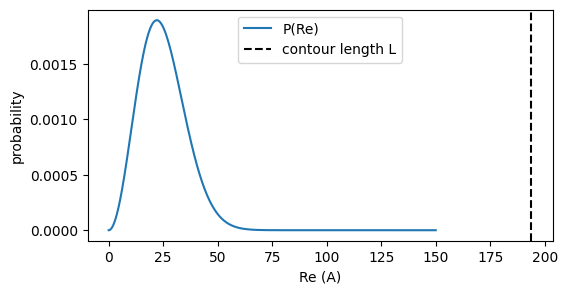

In [4]:
r, p = model.get_end_to_end_distribution()
L = len(seq) * 3.8

plt.figure(figsize=(6, 3))
plt.plot(r, p, label='P(Re)')
plt.axvline(L, ls='--', color='k', label='contour length L')
plt.xlabel('Re (A)')
plt.ylabel('probability')
plt.legend()
plt.show()

## Varying the segment length `b`

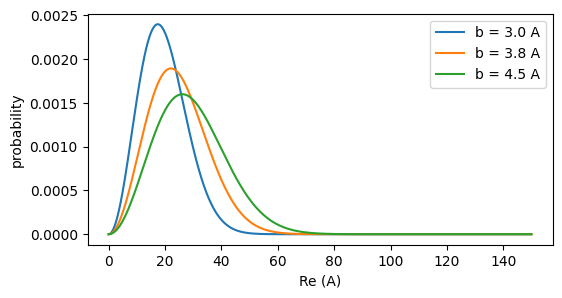

In [5]:
plt.figure(figsize=(6, 3))
for b in [3.0, 3.8, 4.5]:
    r, p = FreelyJointedChain(seq, b=b).get_end_to_end_distribution()
    plt.plot(r, p, label=f'b = {b} A')
plt.xlabel('Re (A)')
plt.ylabel('probability')
plt.legend()
plt.show()